# Fine-tune TinyStories 19M base model to summarize stories

We will fine-tune `tiny-stories-19M` base model to summarize the Stories. Earlier, I have pre-trained the model on [TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories) dataset to generate tiny stories.

The model can be found here: https://huggingface.co/SauravP97/tiny-stories-19M

### Description about the model:

This is a reproduction of a 19.3 million parameter language model from scratch by following the paper [TinyStories: How Small Can Language Models Be and Still Speak Coherent English?](https://arxiv.org/pdf/2305.07759). The goal of this project is to demonstrate that a very small transformer model, when trained on a simplified synthetic dataset, can generate fluent, grammatically correct and consistent short stories.

### TinyStories instruct dataset:

The dataset holds a list of stories along with a concise summary of it.
Dataset: https://huggingface.co/datasets/roneneldan/TinyStoriesInstruct

In [3]:
from datasets import load_dataset, load_from_disk

# If you're running for the first time, uncomment the below line and download the dataset from the HF-Hub
# tiny_story_instruct_dataset = load_dataset('roneneldan/TinyStoriesInstruct')

### Expected Output ###
# Generating train split: 100%|██████████| 21755681/21755681 [00:09<00:00, 2394403.45 examples/s]
# Generating validation split: 100%|██████████| 218380/218380 [00:00<00:00, 844330.12 examples/s]
### Expected Output ###

# Uncomment below line to save the loaded dataset (from hf hub) to disk
# tiny_story_instruct_dataset.save_to_disk('./tiny-stories-instruct-dataset/')

### Expected Output ###
# Saving the dataset (6/6 shards): 100%|██████████| 21755681/21755681 [00:02<00:00, 10705866.06 examples/s]
# Saving the dataset (1/1 shards): 100%|██████████| 218380/218380 [00:00<00:00, 11119837.17 examples/s]
### Expected Output ###


In [4]:
tiny_story_instruct_dataset = load_from_disk('./tiny-stories-instruct-dataset')

In [5]:
tiny_story_instruct_dataset

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 21755681
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 218380
    })
})

## Processing the Instruct-dataset

Currently the dataset has a single column `text` which has stories and summaries together. The below method structures the stories and their summaries in a list of pairs which can be used later for training.

Looking at the current instruct dataset:

<img src="./media/tiny-stories-instruct-dataset.png" width="550" height="400" />

In [6]:
END_OF_TEXT = '<|endoftext|>'

def get_story(dataset, index):
    story = []
    start_ind = index
    while True:
        if index >= len(dataset):
            break
        story_line = dataset[index]['text']
        if story_line.strip() == END_OF_TEXT:
            break
        if story_line.strip():
            if index == start_ind and story_line.startswith('Story:'):
                # Remove 'Story:' prefix (if present) in the first line of the Story
                story.append(story_line.removeprefix('Story:'))
            else:
                story.append(story_line)
        index += 1

    return ' '.join(story)

def transform_dataset(dataset):
    # Runtime of approx 4-5 mins in my Mac (CPU) with 32 Gigs of RAM.
    log_intervals = 1000000
    count = 0
    total = len(dataset)
    story_summary_dataset = []
    current_story = ''
    current_summary = ''
    faulty_rows = 0

    for ind, line in enumerate(dataset):
        if line['text'].startswith('Summary:'):
            current_summary = line['text'].removeprefix('Summary: ')
        if line['text'].startswith('Story:'):
            current_story = get_story(dataset, ind)
        if line['text'].strip() == END_OF_TEXT:
            if current_story == '' or current_summary == '':
                print(f'Either Story or Summary is empty: {faulty_rows}')
                faulty_rows+=1
            else:
                story_summary_dataset.append((current_story, current_summary))
            # reset the story and summary since the current item is completed
            current_story = ''
            current_summary = ''

        count += 1
        if count % log_intervals == 0:
            print(f'Count: {count} / {total}, Percentage: {(count/total) * 100.0}')
    
    return story_summary_dataset

tiny_story_summary_pairs = transform_dataset(tiny_story_instruct_dataset['train'])

Count: 1000000 / 21755681, Percentage: 4.596500564611147
Count: 2000000 / 21755681, Percentage: 9.193001129222294
Either Story or Summary is empty: 0
Count: 3000000 / 21755681, Percentage: 13.789501693833442
Count: 4000000 / 21755681, Percentage: 18.386002258444588
Count: 5000000 / 21755681, Percentage: 22.982502823055732
Either Story or Summary is empty: 1
Count: 6000000 / 21755681, Percentage: 27.579003387666884
Count: 7000000 / 21755681, Percentage: 32.17550395227803
Count: 8000000 / 21755681, Percentage: 36.772004516889176
Count: 9000000 / 21755681, Percentage: 41.368505081500324
Count: 10000000 / 21755681, Percentage: 45.965005646111464
Count: 11000000 / 21755681, Percentage: 50.56150621072262
Count: 12000000 / 21755681, Percentage: 55.15800677533377
Count: 13000000 / 21755681, Percentage: 59.75450733994491
Count: 14000000 / 21755681, Percentage: 64.35100790455606
Count: 15000000 / 21755681, Percentage: 68.9475084691672
Count: 16000000 / 21755681, Percentage: 73.54400903377835
Cou

In [28]:
print(
f'''Story: {tiny_story_summary_pairs[1010][0].strip()}

Summary: {tiny_story_summary_pairs[1010][1].strip()}''')

Story: Once upon a time, there was a big ship on the sea. The ship was so big that it could carry lots of things. One day, the ship saw a small boat in the water. The boat was so soft that it looked like a pillow. The ship offered to help the boat and carry it on its back. The boat was so happy and said thank you to the ship. The ship was happy to help the boat and they became good friends.

Summary: A big ship helps a small boat and they become friends.


## Tokenize the dataset

Let's tokenize the Story and Summary pairs.

In [29]:
from transformers import AutoTokenizer, TextStreamer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125M")
tokenizer.pad_token = tokenizer.eos_token

In [30]:
# Running method in parallel and hence processing individual elements. 
def format_and_tokenize_single_dataset(story_summary_pair):
    story = story_summary_pair[0].strip()
    summary = story_summary_pair[1].strip()

    formatted_dataset = f"Story: {story} \nSummary: {summary}{tokenizer.eos_token}"
    formatted_tokenized_dataset = tokenizer.encode(formatted_dataset)

    return formatted_tokenized_dataset

In [31]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm

tasks = (delayed(format_and_tokenize_single_dataset)(pair) for pair in tiny_story_summary_pairs)

# Run in parallel
tokenized_story_summary_pairs = list(tqdm(
    Parallel(n_jobs=-1, return_as="generator", batch_size=10000)(tasks), 
    total=len(tiny_story_summary_pairs), 
    desc="Tokenizing"
))

Tokenizing: 100%|██████████| 2476530/2476530 [03:06<00:00, 13307.88it/s]


In [33]:
from datasets import Dataset

def prepare_tokenized_dataset(tokenized_list, indices_to_keep):
    tokenized_trimmed_list = tokenized_list[:indices_to_keep]
    tokenized_dataset_dict = {'input_ids': tokenized_trimmed_list}

    hf_dataset = Dataset.from_dict(tokenized_dataset_dict)

    return hf_dataset

In [34]:
hf_tokenized_dataset = prepare_tokenized_dataset(
    tokenized_story_summary_pairs,
    indices_to_keep=10000
)

In [35]:
hf_tokenized_dataset

Dataset({
    features: ['input_ids'],
    num_rows: 10000
})

In [36]:
tokenizer.decode(hf_tokenized_dataset[1010])

'Story: Once upon a time, there was a big ship on the sea. The ship was so big that it could carry lots of things. One day, the ship saw a small boat in the water. The boat was so soft that it looked like a pillow. The ship offered to help the boat and carry it on its back. The boat was so happy and said thank you to the ship. The ship was happy to help the boat and they became good friends. \nSummary: A big ship helps a small boat and they become friends.<|endoftext|>'

In [ ]:
# Save the tokenized dataset locally
# hf_tokenized_dataset.save_to_disk('./tiny-story-summary-tokenized/')

In [ ]:
# Load Tokenizer from the local disk
# from datasets import load_from_disk

# tokenized_story_summary_pairs = load_from_disk('./tiny-story-summary-tokenized')
# tokenized_story_summary_pairs

In [ ]:
from torch.optim import AdamW
from transformers import get_scheduler

# Standard learning rate for fine-tuning
learning_rate = 5e-5
num_epochs = 1

# Load model from hugging face
# model_id = 'SauravP97/tiny-stories-19M'

# Load pretrained model from local.
local_model_path = './tiny-stories/models/tiny-story-summarize-19M-44K'
pretrained_model = AutoModelForCausalLM.from_pretrained(local_model_path)

optimizer = AdamW(pretrained_model.parameters(), lr=learning_rate)

# Calculate total training steps
num_training_steps = num_epochs * len(tokenized_story_summary_pairs)

# Set up the learning rate scheduler
lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

Loading weights: 100%|██████████| 108/108 [00:00<00:00, 869.74it/s, Materializing param=transformer.wte.weight]


In [38]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class TinyStoryDataset(Dataset):
    def __init__(self, tokenized_list):
        self.data = tokenized_list['input_ids']
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long)

In [40]:
tokenized_dataset = TinyStoryDataset(hf_tokenized_dataset)

In [41]:
tokenizer.pad_token_id, tokenizer.eos_token_id

(50256, 50256)

In [42]:
print('Update the Pad token:')
tokenizer.pad_token = '...'

Update the Pad token:


In [44]:
tokenizer.pad_token_id, tokenizer.pad_token, tokenizer.vocab_size

(986, '...', 50257)

In [45]:
tokenizer.special_tokens_map

{'bos_token': '<|endoftext|>',
 'eos_token': '<|endoftext|>',
 'unk_token': '<|endoftext|>',
 'pad_token': '...'}

In [46]:
def dynamic_collate_fn(batch):
    pad_token_id = tokenizer.pad_token_id
    
    # 1. Pad the sequences so they all match the longest one in this batch
    padded_input_ids = pad_sequence(batch, batch_first=True, padding_value=pad_token_id)
    
    # 2. For Causal LM, labels are a direct copy of the input_ids
    labels = padded_input_ids.clone()
    
    # 3. Dynamically create the attention mask
    # It creates a tensor of 1s where the token is real, and 0s where it is padding
    attention_masks = (padded_input_ids != pad_token_id).long()

    # 4. Replace padding token ids in labels with -100 to ignore them in loss calculation
    labels[labels == pad_token_id] = -100
    
    # 3. Return the neat dictionary that standard NLP models expect
    return {
        'input_ids': padded_input_ids,
        'attention_mask': attention_masks,
        'labels': labels
    }

In [49]:
train_dataloader = DataLoader(
    tokenized_dataset, 
    batch_size=8, 
    shuffle=True, 
    collate_fn=dynamic_collate_fn
)
first_batch = next(iter(train_dataloader))

first_batch['input_ids'].shape, first_batch['attention_mask'].shape, first_batch['labels'].shape

(torch.Size([8, 392]), torch.Size([8, 392]), torch.Size([8, 392]))

In [50]:
print(tokenizer.decode(first_batch['input_ids'].tolist()[0]))
print('\n')
print(tokenizer.decode([label if label != -100 else tokenizer.pad_token_id for label in first_batch['labels'].tolist()[0]]))

Story: One day, Jane was exploring the forest when she stumbled into a secret cave. The cave was dingy and dark, but Jane stepped inside and saw many strange things. Soon she heard a voice. "Who are you?" asked the voice. Jane was scared, and she stepped back, but then she saw a big bear. "I'm Jane," she said. "Are you dangerous?" The bear gave a big, gentle smile and said, "No, I'm not dangerous. I'm here to explain something to you." The bear then guided Jane to a corner of the cave. On the wall hung a small wooden frame, and the bear said, "This is an ear, and it can help you hear secret sounds of the forest. It will be a very useful tool for exploring this place." Jane was very excited and thanked the bear. She looked forward to trying out the ear and hearing all the wonderful sounds of the forest. 
Summary: Jane discovers a secret cave in the forest and meets a friendly bear who shows her a tool to hear secret sounds of the forest.<|endoftext|>.....................................

In [ ]:
from tqdm.auto import tqdm

progress_bar = tqdm(range(num_training_steps), desc="Training")
pretrained_model.train() # Put model in training mode

losses = []

for epoch in range(num_epochs):
    for batch in train_dataloader:
        if batch['input_ids'].shape[1] > 511:
            continue

        # Move all tensors in the batch to the designated device
        batch = {k: v for k, v in batch.items()}
        
        # 1. Forward pass
        outputs = pretrained_model(**batch)
        loss = outputs.loss
        
        # 2. Backward pass
        loss.backward()
        losses.append(loss)
        
        # 3. Update weights and learning rate
        optimizer.step()
        lr_scheduler.step()
        
        # 4. Clear gradients for the next step
        optimizer.zero_grad()
        
        # Update progress bar and print loss
        progress_bar.update(1)
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

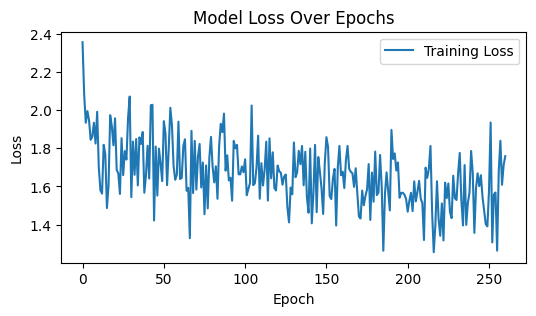

In [53]:
import matplotlib.pyplot as plt

def plot_loss_curve(losses):
    loss_list = [loss.item() for loss in losses]

    # Plot the loss curve
    plt.figure(figsize=(6, 3)) # Optional: adjust figure size
    plt.plot(loss_list, label='Training Loss')

    # Add titles and labels
    plt.title('Model Loss Over Epochs')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend() # Show the legend

    # Display the plot
    plt.show()

plot_loss_curve(losses)

In [81]:
def summarize_story(model, story_summary, logging=True):
    # Move model to evaluation mode
    model.eval()

    # Prompt with a typical TinyStories opening
    story_prompt = story_summary.split('\nSummary: ')[0].strip()
    prompt = story_prompt + '\nSummary: '

    if logging:
        print(prompt)

    inputs = tokenizer(prompt, return_tensors="pt")
    if logging:
        print(f'Shape of Input prompt: {inputs['input_ids'].shape}')

    # Generate
    output_tokens = pretrained_model.generate(
        inputs.input_ids,
        max_new_tokens=100, 
        do_sample=True,
        temperature=1, 
        top_k=50,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    generated_output_tokens = output_tokens[0][inputs.input_ids.shape[1]:]
    decoded_output = tokenizer.decode(generated_output_tokens)
    return decoded_output

In [94]:
inference_id = 9700
decoded_story = tokenizer.decode(tokenized_dataset[inference_id])
print(f'{decoded_story}\n\n')

generated_summary = summarize_story(pretrained_model, decoded_story, logging=False)

print(f'Summary: {generated_summary}')

Story: Once there was a family who lived in a modest house. The family had one room and there was a bookcase that was filled with books. Each night the father would read to his children from the books on the bookcase. One day, the mother said they needed to raise more money to buy a new bookcase. The children helped the family by doing chores and the mother sold her baked goods. After a few weeks of hard work, the family earned enough money to buy a new bookcase. They went to the store and chose a bigger, better one. When they all got home, the children rushed to fill it up with all the books. The family was so happy and they celebrated by making dinner together. Now whenever it was time to read, they all go to the bookcase and pick out a book. And ever since then, the family's house had been filled with peace, love and stories. 
Summary: A family works hard to earn money to buy a new bookcase, which brings them happiness and a love for reading.<|endoftext|>


Summary: 
Summary: A fami